# Leader Effects Analysis

This notebook reads the batch outputs from `outputs/leader_effects_main/` and reproduces the core thesis figures.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from IPython.display import display

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / 'main.py').exists() else cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from visualization import (
    load_leader_effects_outputs,
    plot_leader_effects_content_balance,
    plot_leader_effects_extremism,
    plot_leader_effects_heatmap,
    plot_leader_effects_mode_comparison,
    plot_leader_effects_overview,
)


In [2]:
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'leader_effects_main'
leader_outputs = load_leader_effects_outputs(OUTPUT_DIR)
summary_df = leader_outputs['summary_df']
raw_df = leader_outputs['raw_df']

display(leader_outputs['manifest'])
display(summary_df.head())
display(raw_df.head())


{'created_at_utc': '2026-04-19T09:29:11.137898+00:00',
 'profile_name': 'main',
 'profile_description': 'Core thesis-ready matrix on the tuned simple leader influence baseline.',
 'scenario_name': 'core',
 'scenario_description': 'Main paper matrix over population size, topology, leader mode, and leader share.',
 'output_dir': 'outputs\\leader_effects_main',
 'condition_count': 648,
 'completed_run_count': 648,
 'population_sizes': [500, 1000, 1500],
 'topologies': ['BA', 'ER', 'SBM', 'WS'],
 'leader_modes': ['balanced', 'negative', 'positive'],
 'leader_shares': [0.01, 0.03, 0.05],
 'rounds': [50],
 'seeds': [42, 59, 76, 93, 110, 127],
 'leader_rule': 'Exogenous leader share, then select top-k nodes by realized in-degree rank.',
 'fixed_parameter_base': 'simple leader influence baseline',
 'default_main_rounds': 50,
 'trial_rounds': 25,
 'notes': None}

,profile_name,scenario_name,N,topology,leader_share,leader_mode,leader_selection_method,T_rounds,final_mean_opinion_mean,final_mean_opinion_std,...,actual_creators_total_sem,actual_creators_total_ci_low,actual_creators_total_ci_high,actual_creators_total_n,avg_exposure_size_mean_mean,avg_exposure_size_mean_std,avg_exposure_size_mean_sem,avg_exposure_size_mean_ci_low,avg_exposure_size_mean_ci_high,avg_exposure_size_mean_n
0,main,core,500,BA,0.01,balanced,top_in_degree,50,-0.064157,0.252566,...,76.923338,2029.230257,2330.769743,6,2.729713,0.202430,0.082642,2.567735,2.891691,6
1,main,core,500,BA,0.01,negative,top_in_degree,50,-0.331713,0.058824,...,27.231620,2381.792692,2488.540641,6,3.030700,0.133360,0.054444,2.923989,3.137411,6
2,main,core,500,BA,0.01,positive,top_in_degree,50,0.240489,0.045422,...,38.928710,2241.033062,2393.633604,6,2.834960,0.149926,0.061207,2.714994,2.954926,6
3,main,core,500,BA,0.03,balanced,top_in_degree,50,-0.153350,0.353686,...,113.911491,1745.900144,2192.433189,6,4.028667,0.464887,0.189789,3.656679,4.400654,6
4,main,core,500,BA,0.03,negative,top_in_degree,50,-0.541623,0.052946,...,14.634814,3100.649098,3158.017569,6,5.617387,0.098676,0.040284,5.538430,5.696344,6


,profile_name,scenario_name,N,topology,leader_share,leader_mode,leader_selection_method,T_rounds,seed,condition_id,...,sign_modularity,support_posts,oppose_posts,constructive_posts,toxic_posts,actual_creators_total,avg_exposure_size_mean,content_balance,topology_target_average_degree,network_metadata
0,main,core,500,BA,0.01,balanced,top_in_degree,50,42,N500_BA_01pct_balanced_T50_seed42,...,0.069156,825,1190,1020,995,2015,2.58492,-365,6.0,"{""leader_count"": 5, ""leader_selection_method"":..."
1,main,core,500,BA,0.01,balanced,top_in_degree,50,59,N500_BA_01pct_balanced_T50_seed59,...,0.060622,780,1432,1052,1160,2212,2.67924,-652,6.0,"{""leader_count"": 5, ""leader_selection_method"":..."
2,main,core,500,BA,0.01,balanced,top_in_degree,50,76,N500_BA_01pct_balanced_T50_seed76,...,0.035440,1238,839,1018,1059,2077,2.61724,399,6.0,"{""leader_count"": 5, ""leader_selection_method"":..."
3,main,core,500,BA,0.01,balanced,top_in_degree,50,93,N500_BA_01pct_balanced_T50_seed93,...,0.061502,1668,833,1245,1256,2501,3.06268,835,6.0,"{""leader_count"": 5, ""leader_selection_method"":..."
4,main,core,500,BA,0.01,balanced,top_in_degree,50,110,N500_BA_01pct_balanced_T50_seed110,...,0.053067,746,1518,1198,1066,2264,2.88672,-772,6.0,"{""leader_count"": 5, ""leader_selection_method"":..."


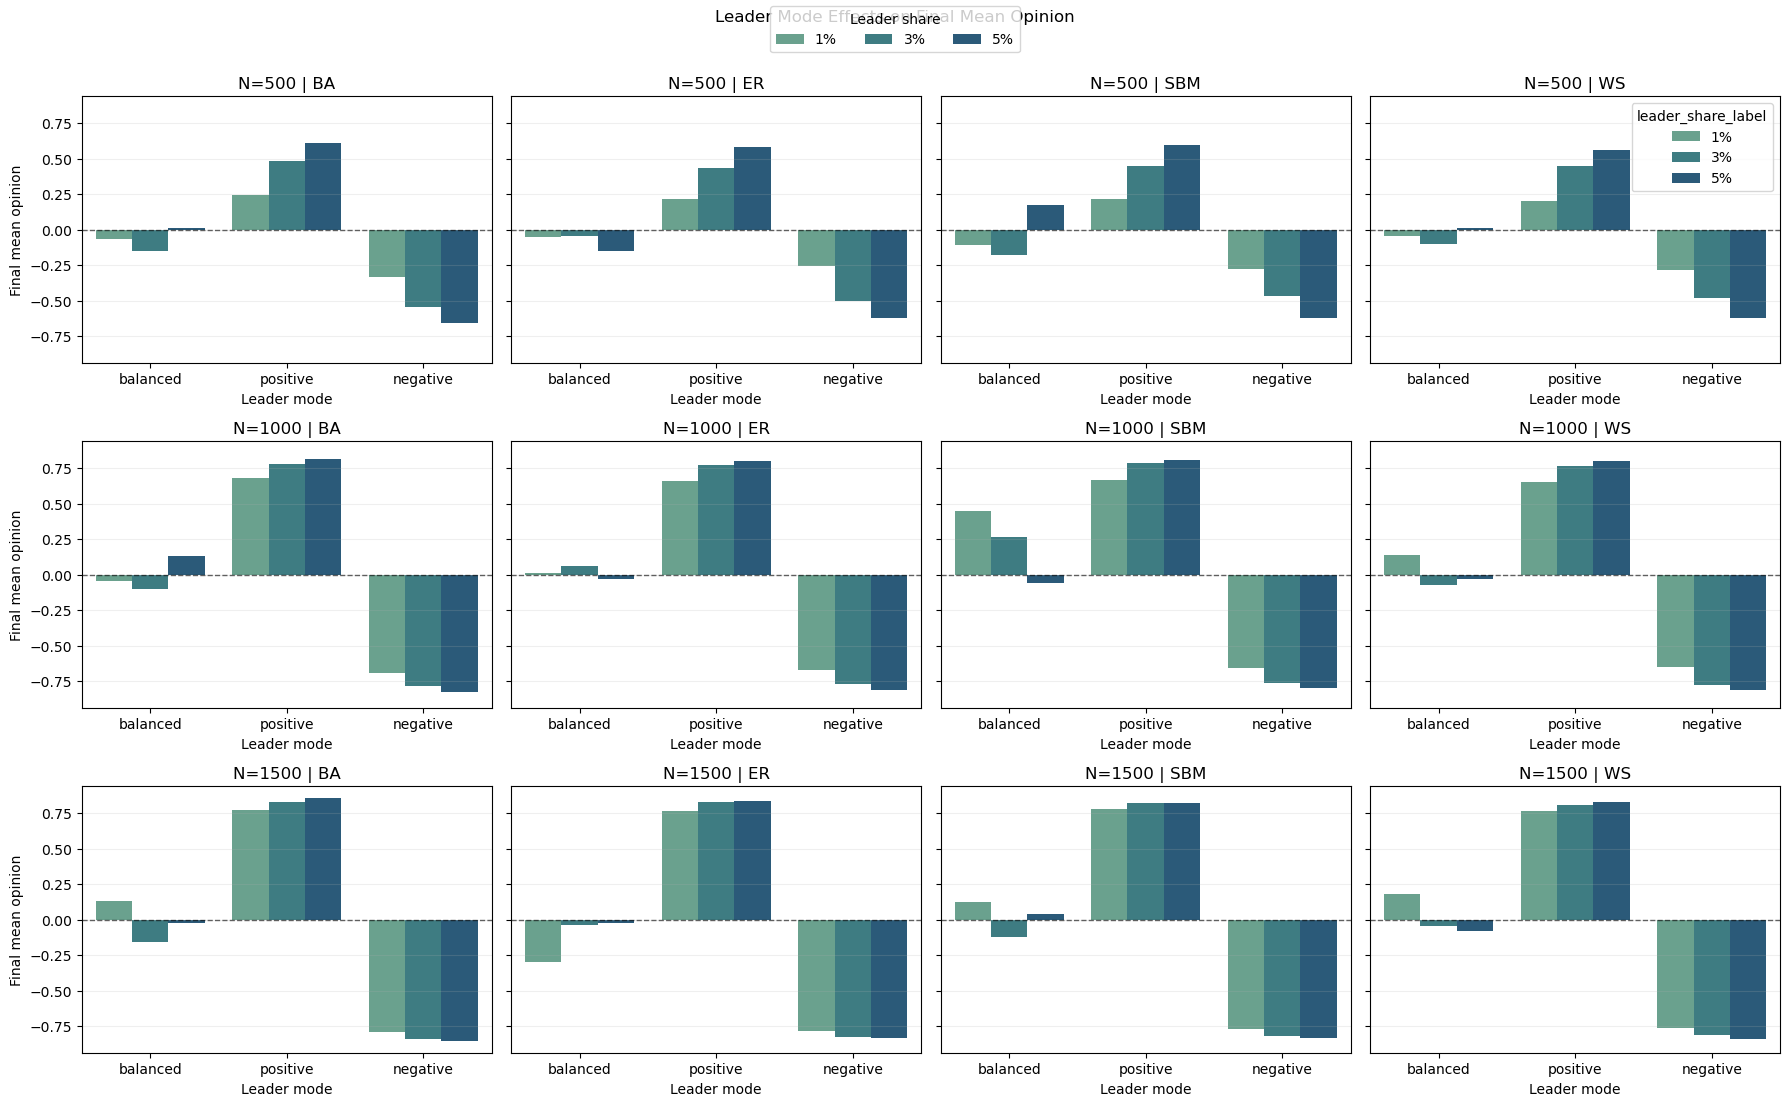

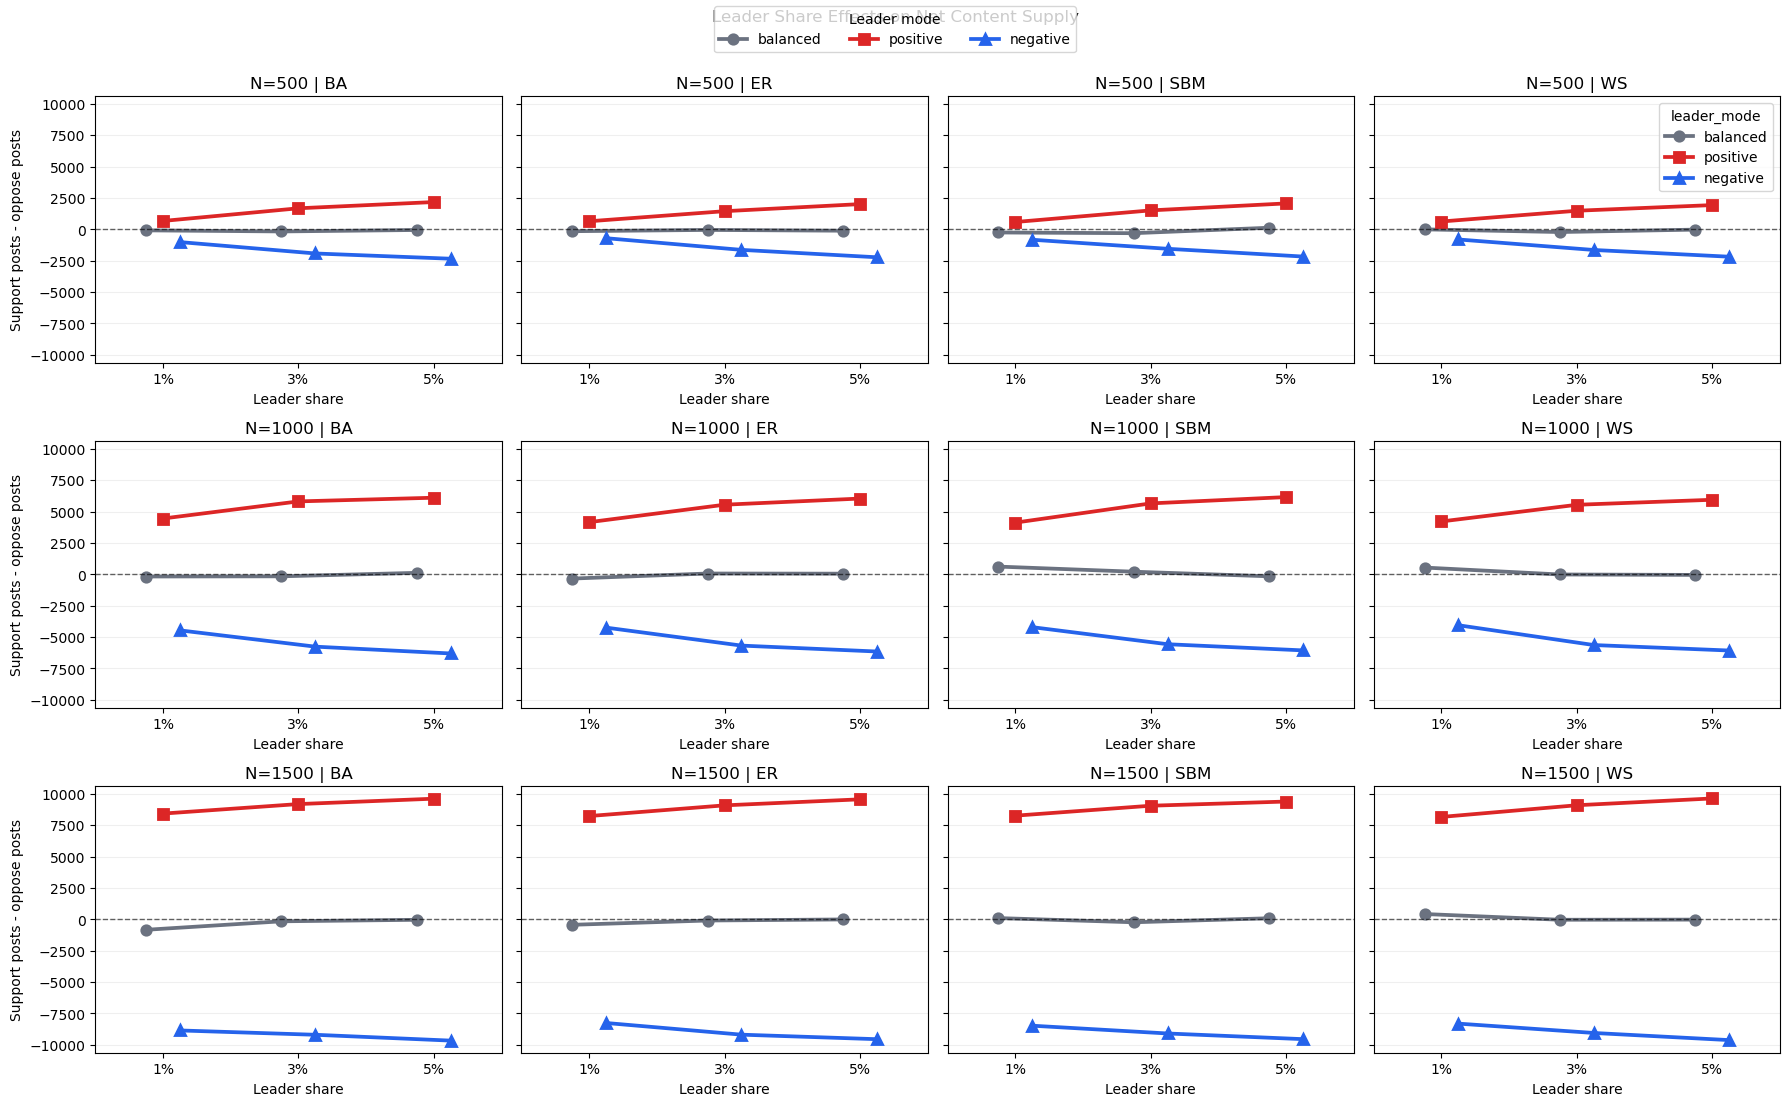

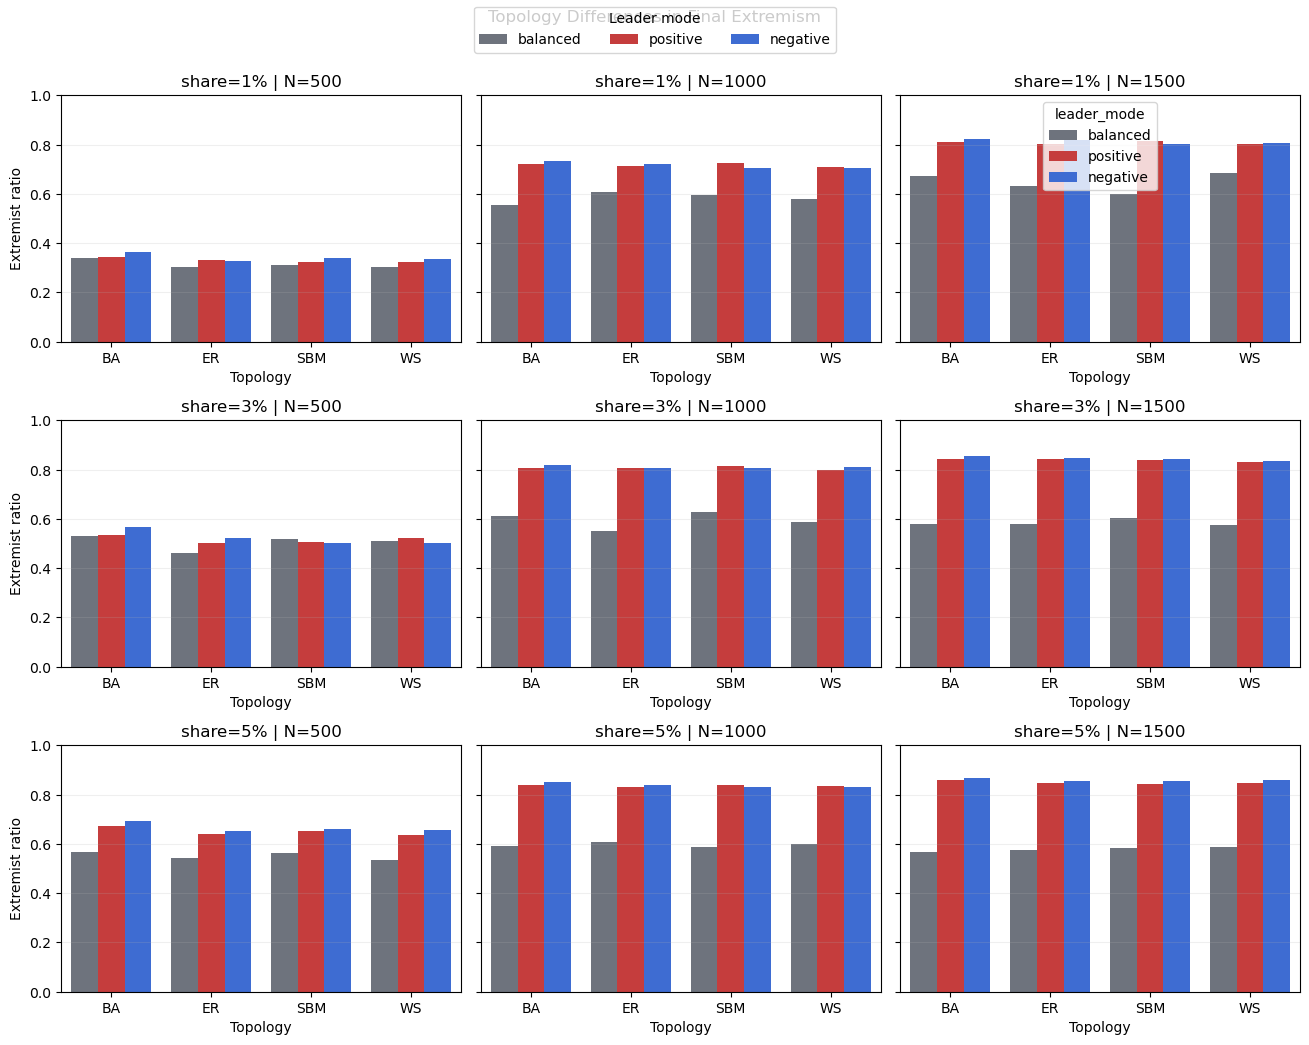

In [3]:
fig, _ = plot_leader_effects_mode_comparison(summary_df)
plt.show()

fig, _ = plot_leader_effects_content_balance(summary_df)
plt.show()

fig, _ = plot_leader_effects_extremism(summary_df)
plt.show()


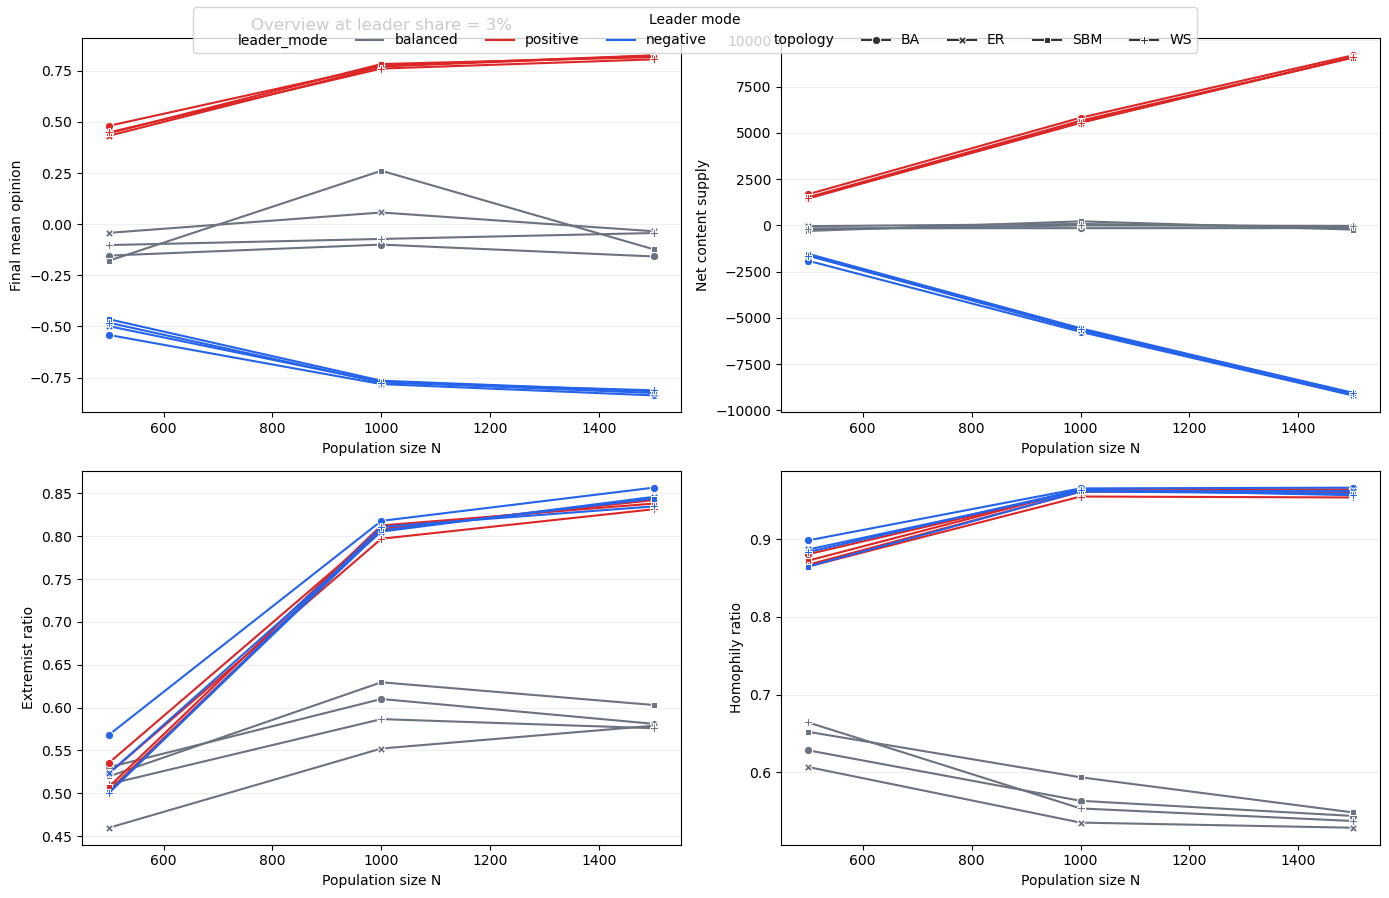

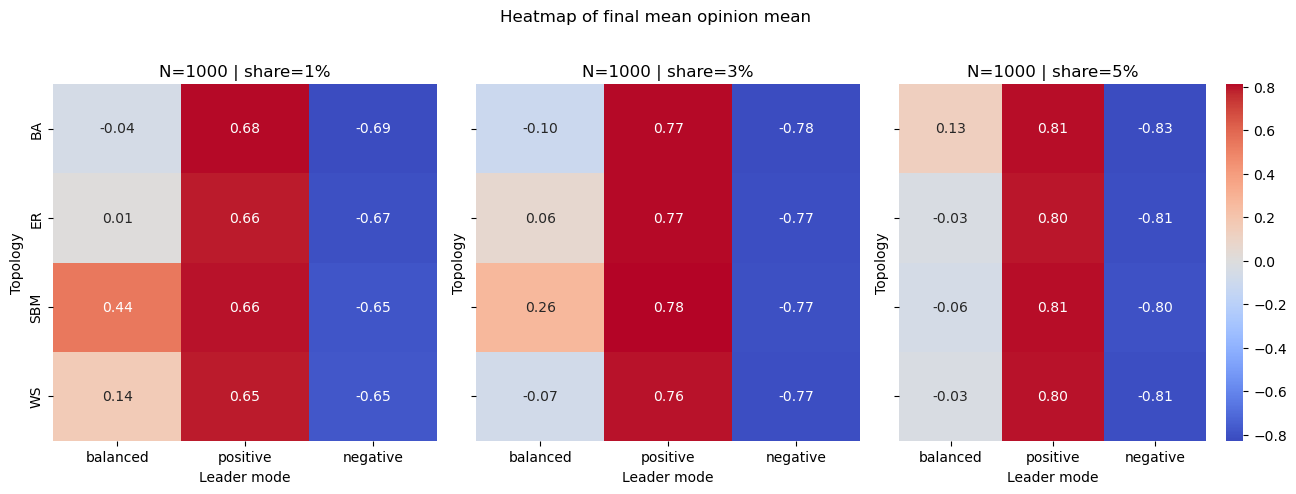

In [4]:
fig, _ = plot_leader_effects_overview(summary_df)
plt.show()

fig, _ = plot_leader_effects_heatmap(summary_df, metric='final_mean_opinion_mean', fixed_n=1000)
plt.show()


In [5]:
benchmark_table = (
    summary_df[summary_df['leader_share'].round(4) == 0.03]
    .sort_values(['N', 'topology', 'leader_mode'])
    [[
        'N', 'topology', 'leader_mode', 'final_mean_opinion_mean',
        'final_mean_abs_opinion_mean', 'extremist_ratio_mean',
        'content_balance_mean', 'homophily_ratio_mean'
    ]]
)
display(benchmark_table)


,N,topology,leader_mode,final_mean_opinion_mean,final_mean_abs_opinion_mean,extremist_ratio_mean,content_balance_mean,homophily_ratio_mean
3,500,BA,balanced,-0.153350,0.658851,0.530333,-162.833333,0.628182
4,500,BA,negative,-0.541623,0.688799,0.568333,-1918.000000,0.898318
5,500,BA,positive,0.481146,0.674725,0.535667,1683.833333,0.880537
12,500,ER,balanced,-0.042165,0.611114,0.459667,-41.833333,0.606707
13,500,ER,negative,-0.498843,0.662687,0.523333,-1631.000000,0.886580
14,500,ER,positive,0.432293,0.650535,0.503333,1452.166667,0.867014
21,500,SBM,balanced,-0.178217,0.657474,0.519667,-302.000000,0.651984
22,500,SBM,negative,-0.464842,0.644991,0.501333,-1545.500000,0.864697
23,500,SBM,positive,0.445007,0.651408,0.507667,1516.333333,0.872318
30,500,WS,balanced,-0.101955,0.650613,0.510667,-209.666667,0.664068
